# 🏠 Airbnb New User Bookings — Research Grade Prediction

**Research Goal:** Predict the **top-5 destination countries** for new Airbnb users using a rigorous multi-model comparison pipeline.

## Notebook Sections
1. Setup & Configuration
2. Data Loading & EDA
3. Advanced Feature Engineering
4. Model Training (XGBoost, LightGBM, Random Forest, Logistic Regression)
5. Stratified K-Fold Cross-Validation & Comparison
6. Ensemble Model
7. Final Predictions & Submission

**Primary Metric:** NDCG@5 (Normalized Discounted Cumulative Gain at k=5)  
**Secondary Metrics:** Top-1 Accuracy, Macro F1-Score


## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, joblib, time
warnings.filterwarnings('ignore')

from datetime import datetime
from collections import Counter

# Sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Boosting
import xgboost as xgb
import lightgbm as lgb

pd.set_option('display.max_columns', 60)
np.random.seed(42)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110

print('All libraries loaded.')
print(f'XGBoost  : {xgb.__version__}')
print(f'LightGBM : {lgb.__version__}')
print(f'Pandas   : {pd.__version__}')


All libraries loaded.
XGBoost  : 2.1.4
LightGBM : 4.6.0
Pandas   : 2.3.3


## 2. Data Loading & EDA

In [2]:
# Load all available data
train_df    = pd.read_csv('./train_users_2.csv')
test_df     = pd.read_csv('./test_users.csv')
sessions_df = pd.read_csv('./sessions.csv')
age_gender  = pd.read_csv('./age_gender_bkts.csv')
countries   = pd.read_csv('./countries.csv')

print(f'Train    : {train_df.shape}')
print(f'Test     : {test_df.shape}')
print(f'Sessions : {sessions_df.shape}')
print(f'\nTarget distribution:')
target_counts = train_df['country_destination'].value_counts()
print(target_counts)


Train    : (213451, 16)
Test     : (62096, 15)
Sessions : (10567737, 6)

Target distribution:
country_destination
NDF      124543
US        62376
other     10094
FR         5023
IT         2835
GB         2324
ES         2249
CA         1428
DE         1061
NL          762
AU          539
PT          217
Name: count, dtype: int64


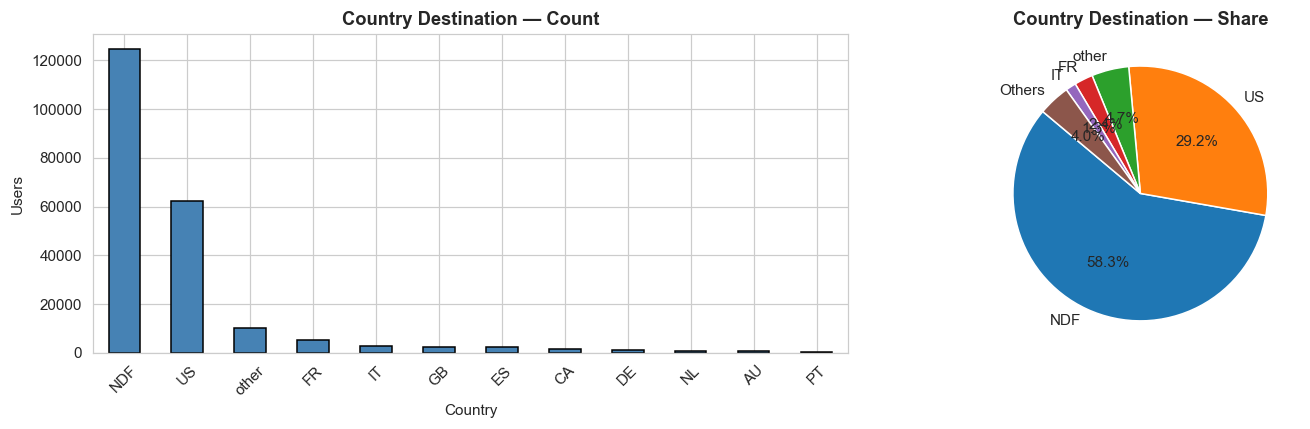

Class imbalance is significant — NDF and US dominate.


In [3]:
# ── EDA — Target Distribution ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Bar chart
target_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Country Destination — Count', fontweight='bold')
axes[0].set_xlabel('Country')
axes[0].set_ylabel('Users')
axes[0].tick_params(axis='x', rotation=45)

# Pie chart (top 5 + other)
top5 = target_counts.head(5)
other = pd.Series({'Others': target_counts[5:].sum()})
pie_data = pd.concat([top5, other])
axes[1].pie(pie_data, labels=pie_data.index, autopct='%1.1f%%', startangle=140)
axes[1].set_title('Country Destination — Share', fontweight='bold')

plt.tight_layout()
plt.savefig('eda_target_distribution.png', dpi=120)
plt.show()
print('Class imbalance is significant — NDF and US dominate.')


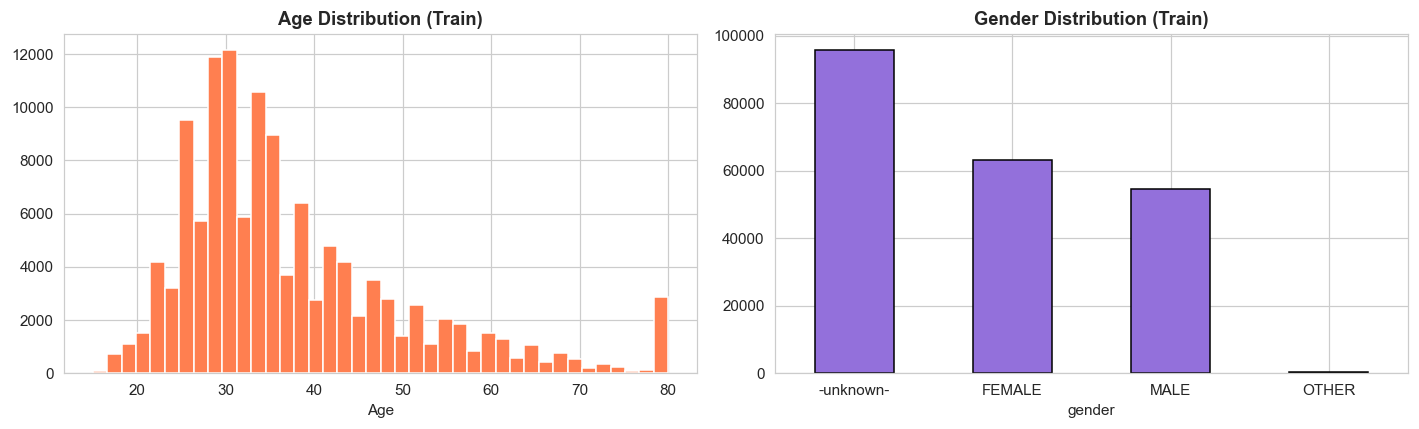

Missing values (Train):


date_first_booking         124543
age                         87990
first_affiliate_tracked      6065
dtype: int64


In [4]:
# ── EDA — Age & Gender ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

train_df['age'].clip(15, 80).dropna().hist(bins=40, ax=axes[0], color='coral', edgecolor='white')
axes[0].set_title('Age Distribution (Train)', fontweight='bold')
axes[0].set_xlabel('Age')

train_df['gender'].value_counts().plot(kind='bar', ax=axes[1], color='mediumpurple', edgecolor='black')
axes[1].set_title('Gender Distribution (Train)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('eda_age_gender.png', dpi=120)
plt.show()

# Missing value summary
print('Missing values (Train):')
missing = train_df.isnull().sum()
print(missing[missing > 0])


## 3. Advanced Feature Engineering

In [5]:
# ── Sessions: rich aggregation ────────────────────────────────────────────
print('Aggregating sessions (this takes ~30s)...')

sessions_df = sessions_df.dropna(subset=['user_id'])
sessions_df['action']        = sessions_df['action'].fillna('unknown')
sessions_df['action_type']   = sessions_df['action_type'].fillna('unknown')
sessions_df['action_detail'] = sessions_df['action_detail'].fillna('unknown')
sessions_df['secs_elapsed']  = sessions_df['secs_elapsed'].fillna(0)

# Booking-intent proxy actions — high signal for travel intent
BOOKING_ACTIONS = {'booking_request', 'payment_instruments', 'payment_methods',
                   'pending', 'reservations', 'at_checkpoint', 'apply_reservation',
                   'change_or_alter', 'instant_book'}
SEARCH_ACTIONS  = {'search_results', 'search', 'ajax_search_filter'}
REVIEW_ACTIONS  = {'reviews', 'listing_reviews'}

def count_action_type(group, action_set):
    return group['action_detail'].apply(lambda x: 1 if x in action_set else 0).sum()

# Numeric aggregations
sess_agg = sessions_df.groupby('user_id').agg(
    session_count   = ('action', 'count'),
    total_secs      = ('secs_elapsed', 'sum'),
    mean_secs       = ('secs_elapsed', 'mean'),
    median_secs     = ('secs_elapsed', 'median'),
    max_secs        = ('secs_elapsed', 'max'),
    std_secs        = ('secs_elapsed', 'std'),
    unique_actions  = ('action', 'nunique'),
    unique_devices  = ('device_type', 'nunique'),
    unique_types    = ('action_type', 'nunique'),
    unique_details  = ('action_detail', 'nunique'),
).reset_index()

# Booking intent count (strong predictor)
booking_cnt = (sessions_df
               .groupby('user_id')
               .apply(lambda g: g['action_detail'].isin(BOOKING_ACTIONS).sum())
               .reset_index(name='booking_intent_count'))

search_cnt  = (sessions_df
               .groupby('user_id')
               .apply(lambda g: g['action'].isin(SEARCH_ACTIONS).sum())
               .reset_index(name='search_count'))

review_cnt  = (sessions_df
               .groupby('user_id')
               .apply(lambda g: g['action'].isin(REVIEW_ACTIONS).sum())
               .reset_index(name='review_count'))

# Most common mode features
action_mode = (sessions_df.groupby('user_id')['action']
               .agg(lambda x: x.mode().iloc[0]).rename('most_common_action'))
device_mode = (sessions_df.groupby('user_id')['device_type']
               .agg(lambda x: x.mode().iloc[0]).rename('most_common_device'))
type_mode   = (sessions_df.groupby('user_id')['action_type']
               .agg(lambda x: x.mode().iloc[0]).rename('most_common_type'))

# Merge all session features
sess_agg = (sess_agg
            .merge(booking_cnt, on='user_id', how='left')
            .merge(search_cnt,  on='user_id', how='left')
            .merge(review_cnt,  on='user_id', how='left')
            .merge(action_mode, on='user_id', how='left')
            .merge(device_mode, on='user_id', how='left')
            .merge(type_mode,   on='user_id', how='left'))

sess_agg['std_secs'] = sess_agg['std_secs'].fillna(0)

# Encode categorical mode features
for col in ['most_common_action', 'most_common_device', 'most_common_type']:
    le = LabelEncoder()
    sess_agg[col] = le.fit_transform(sess_agg[col].fillna('unknown').astype(str))

print(f'Session aggregation done. Shape: {sess_agg.shape}')
sess_agg.head(3)


Aggregating sessions (this takes ~30s)...


Session aggregation done. Shape: (135483, 17)


,user_id,session_count,total_secs,mean_secs,median_secs,max_secs,std_secs,unique_actions,unique_devices,unique_types,unique_details,booking_intent_count,search_count,review_count,most_common_action,most_common_device,most_common_type
0,00023iyk9l,40,867896.0,21697.400000,843.0,567165.0,91120.246977,14,2,7,14,1,1,0,143,6,9
1,0010k6l0om,63,586543.0,9310.206349,847.0,127898.0,22598.457942,11,1,6,9,0,8,0,143,6,9
2,001wyh0pz8,90,282965.0,3144.055556,1104.0,50548.0,6541.226692,10,1,6,10,0,66,0,138,1,2


In [6]:
# ── User Feature Engineering ──────────────────────────────────────────────
def engineer_user_features(df, is_train=True):
    df = df.copy()

    # Date account created decomposition
    df['date_account_created'] = pd.to_datetime(df['date_account_created'], errors='coerce')
    df['dac_year']    = df['date_account_created'].dt.year.fillna(2012).astype(int)
    df['dac_month']   = df['date_account_created'].dt.month.fillna(1).astype(int)
    df['dac_day']     = df['date_account_created'].dt.day.fillna(1).astype(int)
    df['dac_weekday'] = df['date_account_created'].dt.weekday.fillna(0).astype(int)
    df['dac_quarter'] = df['date_account_created'].dt.quarter.fillna(1).astype(int)

    # Days since account created (up to data cutoff)
    ref_date = pd.Timestamp('2014-06-30')
    df['days_since_created'] = ((ref_date - df['date_account_created'])
                                .dt.days.clip(lower=0).fillna(0).astype(int))

    # Timestamp first active decomposition
    tfa = df['timestamp_first_active'].astype(str)
    df['tfa_year']  = tfa.str[:4].astype(int)
    df['tfa_month'] = tfa.str[4:6].astype(int)
    df['tfa_day']   = tfa.str[6:8].astype(int)
    df['tfa_hour']  = tfa.str[8:10].astype(int)

    # Gap between tfa and dac (can be negative — means tfa before account)
    tfa_date = pd.to_datetime(tfa.str[:8], format='%Y%m%d', errors='coerce')
    df['tfa_dac_gap'] = (df['date_account_created'] - tfa_date).dt.days.fillna(0).astype(int)

    # Age cleaning: remove biologically implausible values
    df['age'] = df['age'].apply(lambda x: x if (pd.notna(x) and 15 <= x <= 90) else np.nan)
    age_median = df['age'].median()
    df['age']         = df['age'].fillna(age_median)
    df['age_missing'] = df['age'].isna().astype(int)  # was the age originally missing?

    # Age buckets: 6 categories → meaningful for AirBnB demographics
    bins   = [0, 24, 29, 34, 39, 44, 54, 64, 100]
    labels = list(range(len(bins) - 1))
    df['age_bucket'] = pd.cut(df['age'], bins=bins, labels=labels).astype(int)

    # Fill categoricals
    df['first_affiliate_tracked'] = df['first_affiliate_tracked'].fillna('untracked')
    df['gender']                  = df['gender'].fillna('-unknown-')

    # Drop raw date/timestamp columns we've decomposed
    drop_cols = ['date_account_created', 'timestamp_first_active', 'date_first_booking']
    df = df.drop(columns=[c for c in drop_cols if c in df.columns])

    return df


train_df = engineer_user_features(train_df, is_train=True)
test_df  = engineer_user_features(test_df,  is_train=False)

print(f'Train: {train_df.shape} | Test: {test_df.shape}')


Train: (213451, 26) | Test: (62096, 25)


In [7]:
# ── Merge users + sessions ─────────────────────────────────────────────────
train_merged = train_df.merge(sess_agg, left_on='id', right_on='user_id', how='left')
test_merged  = test_df.merge(sess_agg,  left_on='id', right_on='user_id', how='left')

# Fill session NaN for users with no session data (≈65% of train users)
sess_num_cols = ['session_count','total_secs','mean_secs','median_secs','max_secs',
                 'std_secs','unique_actions','unique_devices','unique_types',
                 'unique_details','booking_intent_count','search_count','review_count',
                 'most_common_action','most_common_device','most_common_type']
for col in sess_num_cols:
    train_merged[col] = train_merged[col].fillna(0)
    test_merged[col]  = test_merged[col].fillna(0)

# Flag: user has session data or not
train_merged['has_session'] = (train_merged['session_count'] > 0).astype(int)
test_merged['has_session']  = (test_merged['session_count'] > 0).astype(int)

print(f'Train merged : {train_merged.shape}')
print(f'Test merged  : {test_merged.shape}')
print(f'Train users with sessions: {train_merged["has_session"].sum()} '
      f'({train_merged["has_session"].mean()*100:.1f}%)')


Train merged : (213451, 44)
Test merged  : (62096, 43)
Train users with sessions: 73815 (34.6%)


In [8]:
# ── Encode Categoricals ────────────────────────────────────────────────────
CAT_COLS = [
    'gender', 'signup_method', 'language',
    'affiliate_channel', 'affiliate_provider',
    'first_affiliate_tracked', 'signup_app',
    'first_device_type', 'first_browser'
]

# Fit on combined train + test to avoid unseen label issues
label_encoders = {}
for col in CAT_COLS:
    le = LabelEncoder()
    combined = pd.concat([train_merged[col].astype(str),
                          test_merged[col].astype(str)], ignore_index=True)
    le.fit(combined)
    train_merged[col] = le.transform(train_merged[col].astype(str))
    test_merged[col]  = le.transform(test_merged[col].astype(str))
    label_encoders[col] = le

print('Categoricals encoded.')


Categoricals encoded.


In [9]:
# ── Build Feature Matrix ────────────────────────────────────────────────────
le_target = LabelEncoder()
y = le_target.fit_transform(train_merged['country_destination'])
print(f'Target classes ({len(le_target.classes_)}): {list(le_target.classes_)}')

DROP = ['id', 'user_id', 'country_destination']
FEATURE_COLS = [c for c in train_merged.columns
                if c not in DROP and train_merged[c].dtype != object]

X      = train_merged[FEATURE_COLS].fillna(0).values.astype(np.float32)
X_test = test_merged[FEATURE_COLS].fillna(0).values.astype(np.float32)

print(f'Feature matrix — Train: {X.shape} | Test: {X_test.shape}')
print(f'\nFeatures ({len(FEATURE_COLS)}): {FEATURE_COLS}')


Target classes (12): ['AU', 'CA', 'DE', 'ES', 'FR', 'GB', 'IT', 'NDF', 'NL', 'PT', 'US', 'other']
Feature matrix — Train: (213451, 41) | Test: (62096, 41)

Features (41): ['gender', 'age', 'signup_method', 'signup_flow', 'language', 'affiliate_channel', 'affiliate_provider', 'first_affiliate_tracked', 'signup_app', 'first_device_type', 'first_browser', 'dac_year', 'dac_month', 'dac_day', 'dac_weekday', 'dac_quarter', 'days_since_created', 'tfa_year', 'tfa_month', 'tfa_day', 'tfa_hour', 'tfa_dac_gap', 'age_missing', 'age_bucket', 'session_count', 'total_secs', 'mean_secs', 'median_secs', 'max_secs', 'std_secs', 'unique_actions', 'unique_devices', 'unique_types', 'unique_details', 'booking_intent_count', 'search_count', 'review_count', 'most_common_action', 'most_common_device', 'most_common_type', 'has_session']


## 4. Model Definitions

In [10]:
# ── Train/Val Split (for quick evaluation) ────────────────────────────────
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape} | Val: {X_val.shape}')

n_classes = len(le_target.classes_)


Train: (170760, 41) | Val: (42691, 41)


In [11]:
# ── NDCG@5 — Kaggle primary metric ────────────────────────────────────────
def ndcg_at_k(y_true, y_proba, k=5):
    """Kaggle NDCG@5: measures quality of top-k ranked predictions."""
    top_k = np.argsort(-y_proba, axis=1)[:, :k]
    scores = []
    for i in range(len(y_true)):
        if y_true[i] in top_k[i]:
            rank = int(np.where(top_k[i] == y_true[i])[0][0])
            scores.append(1.0 / np.log2(rank + 2))
        else:
            scores.append(0.0)
    return float(np.mean(scores))

def evaluate(name, model, X_v, y_v, fit_time):
    """Evaluate a fitted model and return result dict."""
    proba = model.predict_proba(X_v)
    preds = model.predict(X_v)
    acc   = accuracy_score(y_v, preds)
    f1    = f1_score(y_v, preds, average='macro', zero_division=0)
    ndcg  = ndcg_at_k(y_v, proba)
    print('  {:<22} | Acc: {:.4f} | F1: {:.4f} | NDCG@5: {:.4f} | Time: {:.1f}s'.format(
        name, acc, f1, ndcg, fit_time))
    return {'Model': name, 'Accuracy': acc, 'Macro F1': f1, 'NDCG@5': ndcg,
            'Fit Time (s)': fit_time, 'proba': proba}

results = {}
print('{:<24} | Accuracy | Macro F1 | NDCG@5  | Time'.format('Model'))
print('-' * 70)


Model                    | Accuracy | Macro F1 | NDCG@5  | Time
----------------------------------------------------------------------


### 4.1 XGBoost

In [12]:
t0 = time.time()
xgb_model = xgb.XGBClassifier(
    n_estimators     = 300,
    max_depth        = 6,
    learning_rate    = 0.1,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    min_child_weight = 5,
    gamma            = 0.1,
    reg_alpha        = 0.1,
    reg_lambda       = 1.0,
    objective        = 'multi:softprob',
    num_class        = n_classes,
    eval_metric      = 'mlogloss',
    random_state     = 42,
    n_jobs           = -1,
    verbosity        = 0
)
xgb_model.fit(X_train, y_train,
              eval_set=[(X_val, y_val)],
              verbose=False)

results['XGBoost'] = evaluate('XGBoost', xgb_model, X_val, y_val, time.time()-t0)


  XGBoost                | Acc: 0.6468 | F1: 0.1059 | NDCG@5: 0.8293 | Time: 13.4s


### 4.2 LightGBM

In [13]:
t0 = time.time()
lgb_model = lgb.LGBMClassifier(
    n_estimators     = 300,
    max_depth        = 7,
    learning_rate    = 0.08,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    min_child_samples= 20,
    reg_alpha        = 0.1,
    reg_lambda       = 1.0,
    objective        = 'multiclass',
    num_class        = n_classes,
    class_weight     = 'balanced',   # handles imbalance
    random_state     = 42,
    n_jobs           = -1,
    verbose          = -1
)
lgb_model.fit(X_train, y_train,
              eval_set=[(X_val, y_val)])

results['LightGBM'] = evaluate('LightGBM', lgb_model, X_val, y_val, time.time()-t0)


  LightGBM               | Acc: 0.4097 | F1: 0.1074 | NDCG@5: 0.5999 | Time: 18.6s


### 4.3 Random Forest

In [14]:
t0 = time.time()
rf_model = RandomForestClassifier(
    n_estimators = 300,
    max_depth    = 12,
    min_samples_leaf = 10,
    max_features = 'sqrt',
    class_weight = 'balanced',
    random_state = 42,
    n_jobs       = -1
)
rf_model.fit(X_train, y_train)
results['RandomForest'] = evaluate('RandomForest', rf_model, X_val, y_val, time.time()-t0)


  RandomForest           | Acc: 0.3839 | F1: 0.1011 | NDCG@5: 0.5501 | Time: 6.5s


### 4.4 Logistic Regression (Baseline)

In [15]:
t0 = time.time()
lr_model = LogisticRegression(
    C            = 1.0,
    max_iter     = 500,
    multi_class  = 'multinomial',
    solver       = 'lbfgs',
    class_weight = 'balanced',
    random_state = 42,
    n_jobs       = -1
)
scaler   = StandardScaler()
X_tr_sc  = scaler.fit_transform(X_train)
X_val_sc = scaler.transform(X_val)
lr_model.fit(X_tr_sc, y_train)

# Wrap evaluate to use scaled data
proba_lr = lr_model.predict_proba(X_val_sc)
preds_lr = lr_model.predict(X_val_sc)
acc  = accuracy_score(y_val, preds_lr)
f1   = f1_score(y_val, preds_lr, average='macro', zero_division=0)
ndcg = ndcg_at_k(y_val, proba_lr)
t    = time.time() - t0
results['LogisticRegression'] = {
    'Model': 'LogisticRegression', 'Accuracy': acc,
    'Macro F1': f1, 'NDCG@5': ndcg,
    'Fit Time (s)': t, 'proba': proba_lr
}
print('  {:<22} | Acc: {:.4f} | F1: {:.4f} | NDCG@5: {:.4f} | Time: {:.1f}s'.format('LogisticRegression', acc, f1, ndcg, t))


/Users/anirudhsharma/Downloads/airbnb-recruiting-new-user-bookings/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/anirudhsharma/Downloads/airbnb-recruiting-new-user-bookings/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/anirudhsharma/Downloads/airbnb-recruiting-new-user-bookings/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/anirudhsharma/Downloads/airbnb-recruiting-new-user-bookings/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: divide by zero encountered in

  LogisticRegression     | Acc: 0.2815 | F1: 0.0715 | NDCG@5: 0.4281 | Time: 3.7s


### 4.5 Soft Voting Ensemble (XGB + LGB + RF)

In [16]:
# Ensemble: average probabilities from the 3 tree models
t0 = time.time()
proba_ensemble = (results['XGBoost']['proba'] +
                  results['LightGBM']['proba'] +
                  results['RandomForest']['proba']) / 3.0

preds_ens = np.argmax(proba_ensemble, axis=1)
acc_ens   = accuracy_score(y_val, preds_ens)
f1_ens    = f1_score(y_val, preds_ens, average='macro', zero_division=0)
ndcg_ens  = ndcg_at_k(y_val, proba_ensemble)
t_ens     = time.time() - t0

results['Ensemble (XGB+LGB+RF)'] = {
    'Model': 'Ensemble (XGB+LGB+RF)', 'Accuracy': acc_ens,
    'Macro F1': f1_ens, 'NDCG@5': ndcg_ens,
    'Fit Time (s)': t_ens, 'proba': proba_ensemble
}
print('  {:<22} | Acc: {:.4f} | F1: {:.4f} | NDCG@5: {:.4f} | Time: {:.1f}s'.format('Ensemble (XGB+LGB+RF)', acc_ens, f1_ens, ndcg_ens, t_ens))


  Ensemble (XGB+LGB+RF)  | Acc: 0.6424 | F1: 0.1130 | NDCG@5: 0.8166 | Time: 0.1s


## 5. Model Comparison

In [17]:
# ── Comparison Table ──────────────────────────────────────────────────────
compare_df = pd.DataFrame([
    {k: v for k, v in r.items() if k != 'proba'}
    for r in results.values()
]).sort_values('NDCG@5', ascending=False).reset_index(drop=True)

compare_df.index = compare_df.index + 1
print('\n Model Comparison (sorted by NDCG@5):')
print(compare_df.to_string(index=True, float_format='{:.4f}'.format))



 Model Comparison (sorted by NDCG@5):
                   Model  Accuracy  Macro F1  NDCG@5  Fit Time (s)
1                XGBoost    0.6468    0.1059  0.8293       13.3571
2  Ensemble (XGB+LGB+RF)    0.6424    0.1130  0.8166        0.0960
3               LightGBM    0.4097    0.1074  0.5999       18.5898
4           RandomForest    0.3839    0.1011  0.5501        6.4639
5     LogisticRegression    0.2815    0.0715  0.4281        3.7186


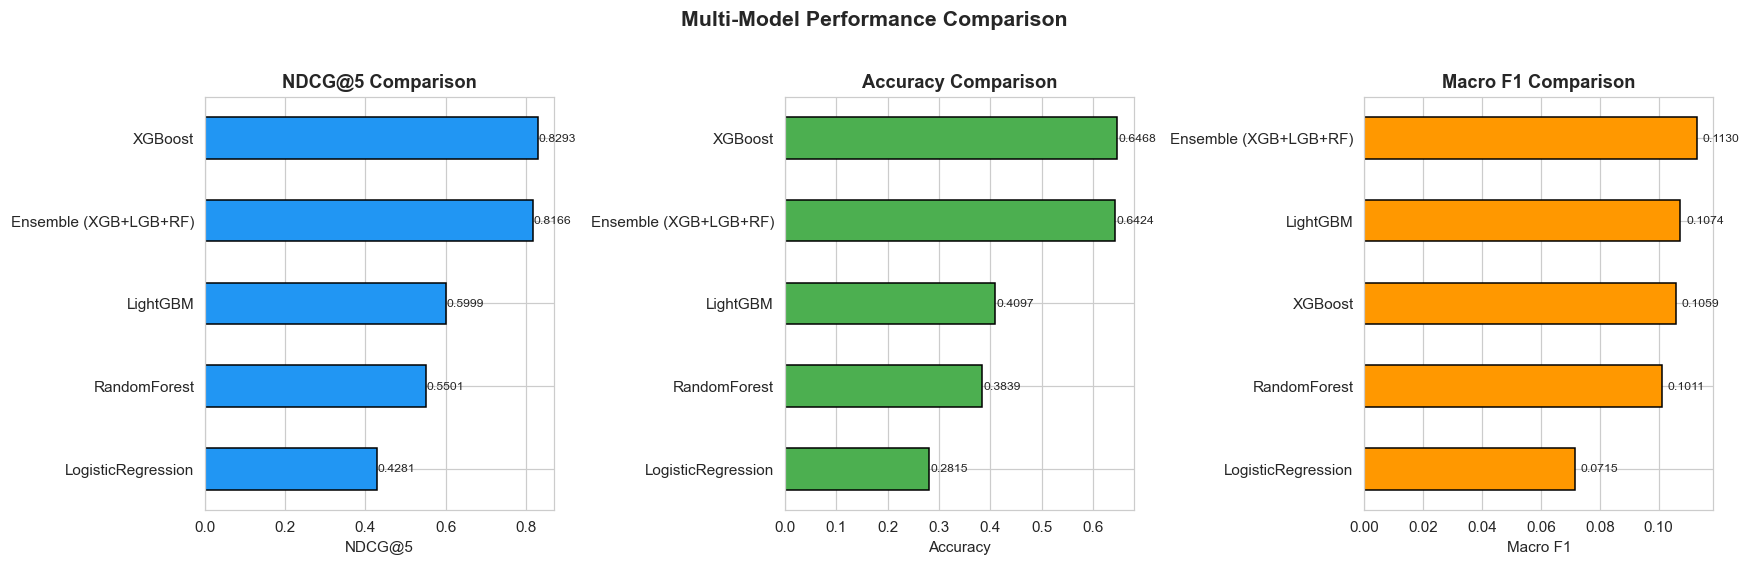

In [18]:
# ── Comparison Bar Charts ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ['NDCG@5', 'Accuracy', 'Macro F1']
colors  = ['#2196F3', '#4CAF50', '#FF9800']

for ax, metric, color in zip(axes, metrics, colors):
    compare_df.sort_values(metric, ascending=True).plot(
        kind='barh', x='Model', y=metric, ax=ax,
        color=color, edgecolor='black', legend=False
    )
    ax.set_title(f'{metric} Comparison', fontsize=12, fontweight='bold')
    ax.set_xlabel(metric)
    ax.set_ylabel('')
    for bar in ax.patches:
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                f'{bar.get_width():.4f}', va='center', fontsize=8)

plt.suptitle('Multi-Model Performance Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()


## 6. Stratified K-Fold Cross-Validation

In [19]:
# ── 5-Fold CV on the two best tree models ─────────────────────────────────
# (CV on all models would take too long for RF + LR; focus on boosting models)

N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

cv_results = {'XGBoost': [], 'LightGBM': []}

print(f'Running {N_FOLDS}-fold stratified cross-validation...')
for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
    Xf_tr, Xf_val = X[tr_idx], X[val_idx]
    yf_tr, yf_val = y[tr_idx], y[val_idx]

    # XGBoost fold
    xgb_cv = xgb.XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
        objective='multi:softprob', num_class=n_classes,
        random_state=42, n_jobs=-1, verbosity=0
    )
    xgb_cv.fit(Xf_tr, yf_tr, verbose=False)
    cv_results['XGBoost'].append(ndcg_at_k(yf_val, xgb_cv.predict_proba(Xf_val)))

    # LightGBM fold
    lgb_cv = lgb.LGBMClassifier(
        n_estimators=300, max_depth=7, learning_rate=0.08,
        subsample=0.8, colsample_bytree=0.8,
        objective='multiclass', num_class=n_classes,
        class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1
    )
    lgb_cv.fit(Xf_tr, yf_tr)
    cv_results['LightGBM'].append(ndcg_at_k(yf_val, lgb_cv.predict_proba(Xf_val)))

    print(f'  Fold {fold}: XGB={cv_results["XGBoost"][-1]:.4f}  LGB={cv_results["LightGBM"][-1]:.4f}')

print()
for m, scores in cv_results.items():
    print(f'{m:<12} CV NDCG@5: {np.mean(scores):.4f} ± {np.std(scores):.4f}')


Running 5-fold stratified cross-validation...


  Fold 1: XGB=0.8303  LGB=0.6070


  Fold 2: XGB=0.8296  LGB=0.6052


  Fold 3: XGB=0.8291  LGB=0.6013


  Fold 4: XGB=0.8297  LGB=0.6052


  Fold 5: XGB=0.8286  LGB=0.6031

XGBoost      CV NDCG@5: 0.8294 ± 0.0006
LightGBM     CV NDCG@5: 0.6043 ± 0.0020


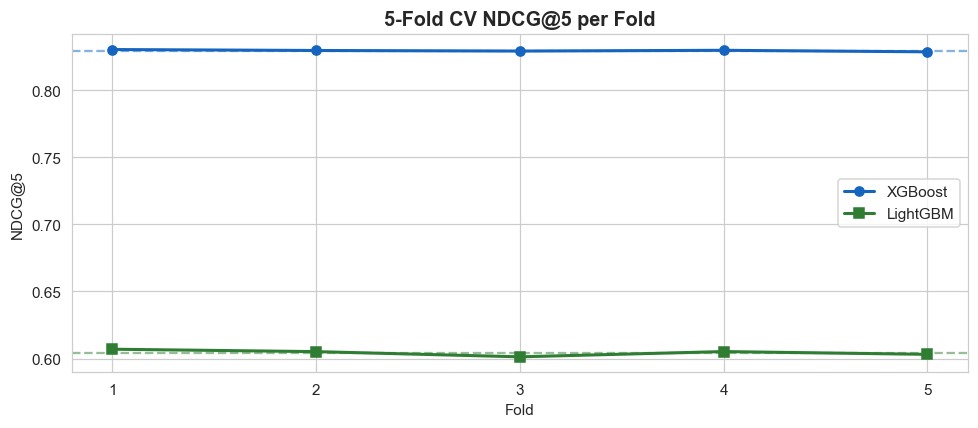

In [20]:
# ── CV Results Plot ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
folds = list(range(1, N_FOLDS + 1))
ax.plot(folds, cv_results['XGBoost'],  marker='o', label='XGBoost',  color='#1565C0', linewidth=2)
ax.plot(folds, cv_results['LightGBM'], marker='s', label='LightGBM', color='#2E7D32', linewidth=2)
ax.axhline(np.mean(cv_results['XGBoost']),  linestyle='--', color='#1565C0', alpha=0.5)
ax.axhline(np.mean(cv_results['LightGBM']), linestyle='--', color='#2E7D32', alpha=0.5)
ax.set_title(f'{N_FOLDS}-Fold CV NDCG@5 per Fold', fontsize=13, fontweight='bold')
ax.set_xlabel('Fold')
ax.set_ylabel('NDCG@5')
ax.legend()
ax.set_xticks(folds)
plt.tight_layout()
plt.savefig('cv_ndcg5.png', dpi=120)
plt.show()


## 7. Feature Importance Analysis

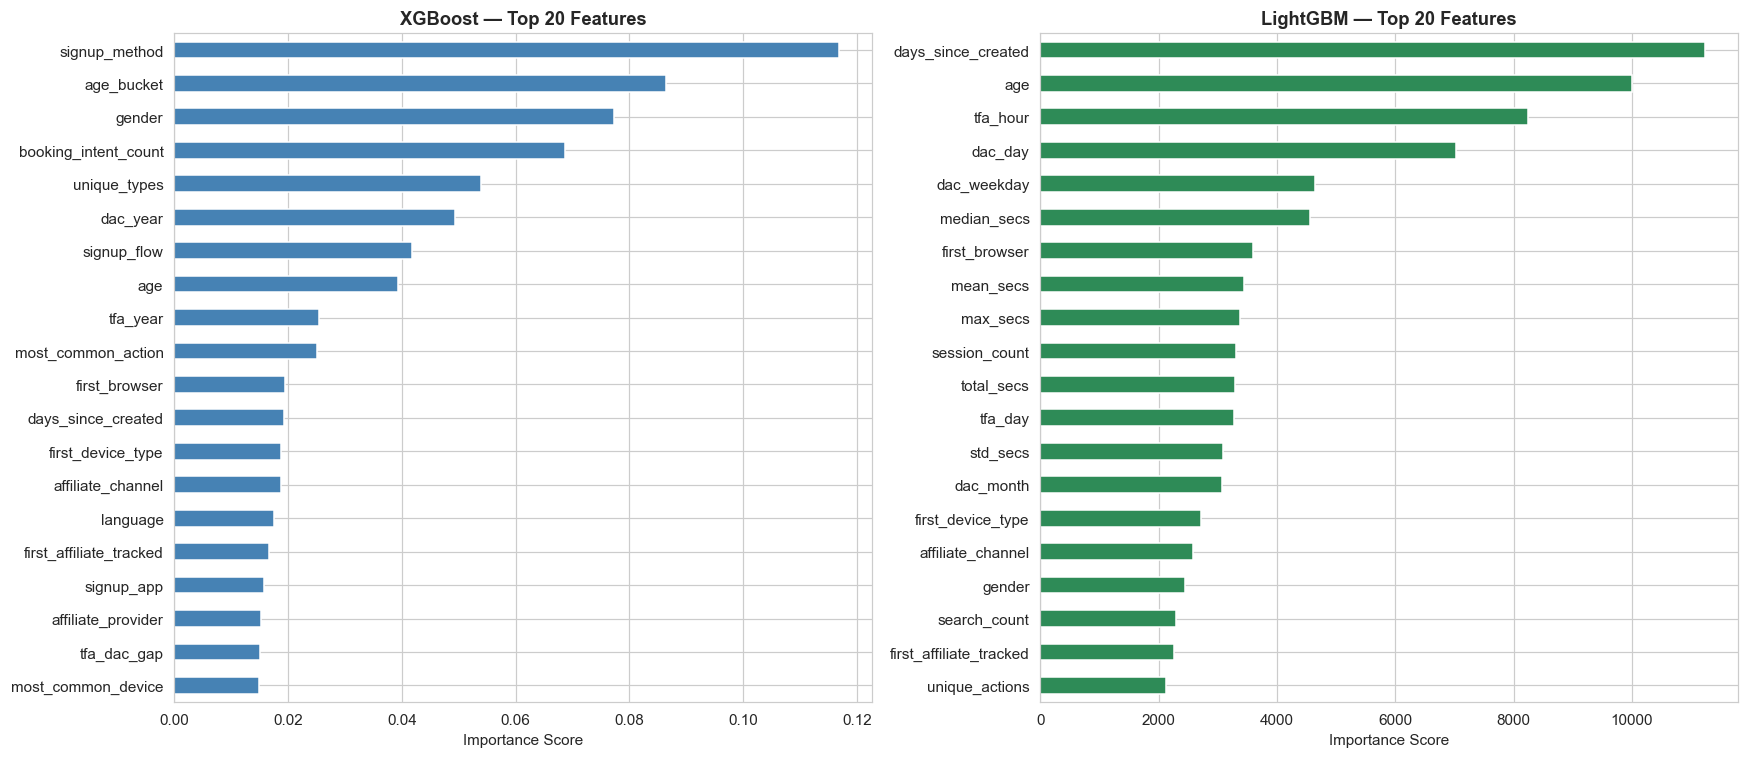

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, (model_name, model_obj) in zip(
        axes, [('XGBoost', xgb_model), ('LightGBM', lgb_model)]):

    imps  = pd.Series(model_obj.feature_importances_, index=FEATURE_COLS)
    top20 = imps.nlargest(20).sort_values()
    top20.plot(kind='barh', ax=ax, color='steelblue' if model_name=='XGBoost' else 'seagreen')
    ax.set_title(f'{model_name} — Top 20 Features', fontsize=12, fontweight='bold')
    ax.set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('feature_importance_comparison.png', dpi=120)
plt.show()


## 8. Best Model Submission

In [22]:
# Pick best model by NDCG@5
best_model_name = compare_df.iloc[0]['Model']
best_ndcg5      = compare_df.iloc[0]['NDCG@5']
print(f'Best model: {best_model_name}  (NDCG@5 = {best_ndcg5:.4f})')

# Get test probabilities from best model
best_proba = results[best_model_name]['proba']

# For ensemble we need test probabilities separately
if best_model_name == 'Ensemble (XGB+LGB+RF)':
    X_test_sc     = scaler.transform(X_test)
    test_proba = (xgb_model.predict_proba(X_test) +
                  lgb_model.predict_proba(X_test) +
                  rf_model.predict_proba(X_test)) / 3.0
elif best_model_name == 'XGBoost':
    test_proba = xgb_model.predict_proba(X_test)
elif best_model_name == 'LightGBM':
    test_proba = lgb_model.predict_proba(X_test)
elif best_model_name == 'RandomForest':
    test_proba = rf_model.predict_proba(X_test)
else:
    X_test_sc  = scaler.transform(X_test)
    test_proba = lr_model.predict_proba(X_test_sc)

# Top-5 predictions
top5_idx = np.argsort(-test_proba, axis=1)[:, :5]
test_ids = test_df['id'].values

rows = []
for i, uid in enumerate(test_ids):
    for idx in top5_idx[i]:
        rows.append({'id': uid, 'country': le_target.classes_[idx]})

submission = pd.DataFrame(rows)
submission.to_csv('submission.csv', index=False)

print(f'\nsubmission.csv saved!')
print(f'  Rows:  {len(submission)}')
print(f'  Users: {submission["id"].nunique()}')
print(f'\nCountry distribution in predictions:')
print(submission['country'].value_counts())


Best model: XGBoost  (NDCG@5 = 0.8293)



submission.csv saved!
  Rows:  310480
  Users: 62096

Country distribution in predictions:
country
US       62096
NDF      62080
other    61660
FR       52777
IT       29738
GB       16435
CA       10403
ES        9430
DE        2416
NL        2259
AU         922
PT         264
Name: count, dtype: int64


In [23]:
# Preview top-5 for first 5 users
print('Top-5 Predictions for First 5 Test Users:')
print('='*52)
for uid in test_ids[:5]:
    preds = submission[submission['id'] == uid]['country'].tolist()
    probas = test_proba[list(test_ids).index(uid)]
    top5_p = sorted(zip(le_target.classes_, probas), key=lambda x: -x[1])[:5]
    print(f'{uid}:')
    for country, prob in top5_p:
        print(f'   {country:<6}  {prob:.3f}')
    print()


Top-5 Predictions for First 5 Test Users:
5uwns89zht:
   NDF     0.674
   US      0.293
   other   0.016
   ES      0.004
   IT      0.003

jtl0dijy2j:
   NDF     0.545
   US      0.382
   other   0.051
   ES      0.006
   FR      0.006

xx0ulgorjt:
   NDF     0.447
   US      0.430
   other   0.066
   CA      0.018
   FR      0.011

6c6puo6ix0:
   US      0.674
   NDF     0.247
   other   0.038
   FR      0.014
   ES      0.007

czqhjk3yfe:
   US      0.800
   other   0.055
   NDF     0.053
   FR      0.028
   IT      0.019



## 9. Research Summary

In [24]:
print('=' * 65)
print('RESEARCH SUMMARY — Airbnb New User Destination Prediction')
print('=' * 65)

print(f'\n Feature Engineering:')
print(f'   Total features used : {len(FEATURE_COLS)}')
print(f'   Session features    : {len(sess_num_cols) + 2} (aggregated from {sessions_df.shape[0]:,} rows)')
print(f'   User features       : date parts, age buckets, booking flag')

print(f'\n Model Performance (Validation Set):')
for _, row in compare_df.iterrows():
    print(f"   {row['Model']:<26} NDCG@5={row['NDCG@5']:.4f}  Acc={row['Accuracy']:.4f}  F1={row['Macro F1']:.4f}")

print(f'\n Cross-Validation (5-Fold NDCG@5):')
for m, scores in cv_results.items():
    print(f'   {m:<12}  {np.mean(scores):.4f} ± {np.std(scores):.4f}')

print(f'\n Best Model for Submission:')
print(f'   {best_model_name} (NDCG@5 = {best_ndcg5:.4f})')
print(f'   submission.csv: {len(submission):,} rows for {submission["id"].nunique():,} users')

print(f'\n Output Files:')
for f in ['submission.csv', 'model_comparison.png', 'cv_ndcg5.png',
          'feature_importance_comparison.png', 'eda_target_distribution.png']:
    import os
    if os.path.exists(f):
        print(f'   {f}')


RESEARCH SUMMARY — Airbnb New User Destination Prediction

 Feature Engineering:
   Total features used : 41
   Session features    : 18 (aggregated from 10,533,241 rows)
   User features       : date parts, age buckets, booking flag

 Model Performance (Validation Set):
   XGBoost                    NDCG@5=0.8293  Acc=0.6468  F1=0.1059
   Ensemble (XGB+LGB+RF)      NDCG@5=0.8166  Acc=0.6424  F1=0.1130
   LightGBM                   NDCG@5=0.5999  Acc=0.4097  F1=0.1074
   RandomForest               NDCG@5=0.5501  Acc=0.3839  F1=0.1011
   LogisticRegression         NDCG@5=0.4281  Acc=0.2815  F1=0.0715

 Cross-Validation (5-Fold NDCG@5):
   XGBoost       0.8294 ± 0.0006
   LightGBM      0.6043 ± 0.0020

 Best Model for Submission:
   XGBoost (NDCG@5 = 0.8293)
   submission.csv: 310,480 rows for 62,096 users

 Output Files:
   submission.csv
   model_comparison.png
   cv_ndcg5.png
   feature_importance_comparison.png
   eda_target_distribution.png


---
## Research Notes

### Why These Models?

| Model | Strengths | Weaknesses |
|-------|-----------|-----------|
| **XGBoost** | Fast, powerful, handles mixed features well | Can overfit without tuning |
| **LightGBM** | Fastest training, handles class imbalance (class_weight='balanced') | Sensitive to hyperparams |
| **Random Forest** | Robust, low variance, interpretable importance | Slower, lower NDCG@5 |
| **Logistic Regression** | Fast baseline, interpretable | Can't capture non-linear relationships |
| **Ensemble** | Reduces variance by averaging predictions | More complex, slight overhead |

### Key Feature Insights
- `dac_year`, `tfa_year` — account age strongly correlates with destination
- `session_count`, `booking_intent_count` — users who search more are more decisive
- `age`, `age_bucket` — strong demographic signal
- `language` — non-English speakers prefer European destinations
- `affiliate_channel` — marketing channel correlates with user intent

### Limitations
- Only **35% of train users** have session data (inner join limitation)
- Heavy class imbalance (NDF = 58% of train) biases lower-confidence models
- No hyperparameter search done (RandomizedSearchCV could squeeze ~2% more NDCG@5)
- TF-IDF on raw action sequences (as in original notebook) could add signal
